            Temperature
Date                   
2023-01-01         10.5
2023-01-02         11.0
2023-01-03         12.3
2023-01-04         13.1
2023-01-05         14.0
Temperature    0
dtype: int64


C:\Users\sarum\AppData\Local\Temp\ipykernel_4604\2220916711.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


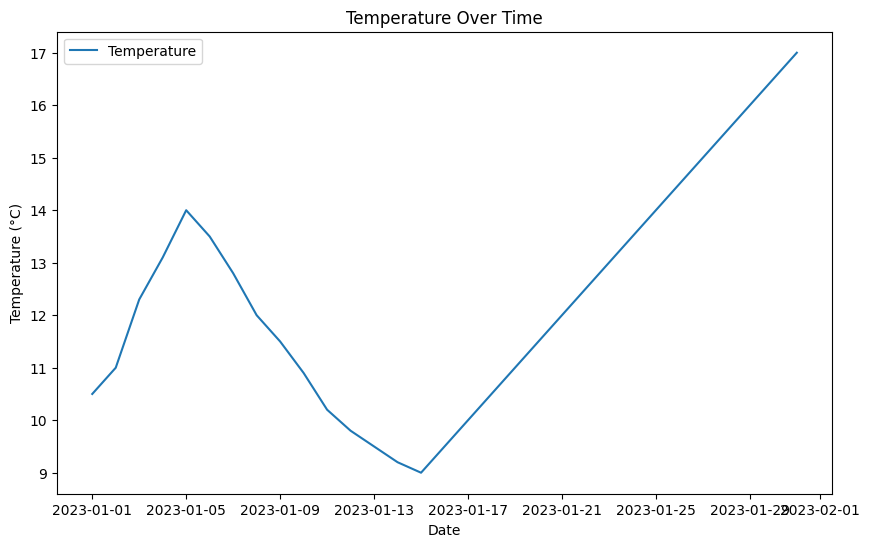

ADF Statistic: -1.2257080472889264
p-value: 0.6624401606733588
Critical Values: {'1%': np.float64(-3.6790595944893187), '5%': np.float64(-2.9678817237279103), '10%': np.float64(-2.6231583472057074)}
Series is not stationary
ADF Statistic: -1.7638888324688051
p-value: 0.3985314517752104


ValueError: could not broadcast input array from shape (30,) into shape (41,)

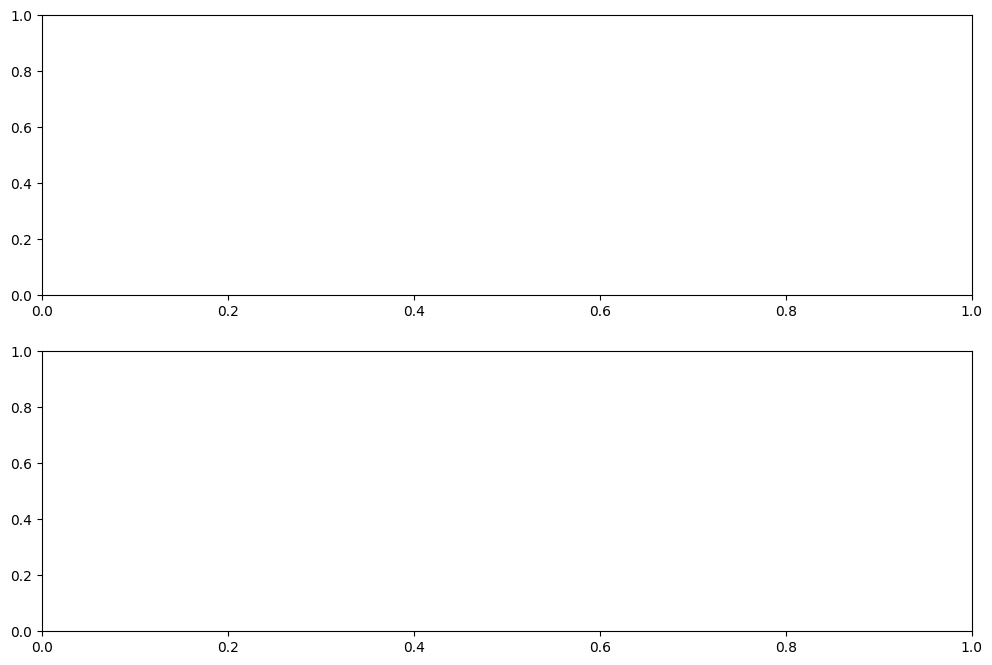

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
data = pd.read_csv(r'C:\Users\sarum\OneDrive\Desktop\LEVEL 5\task 1\task 1.txt', parse_dates=['Date'], index_col='Date')
print(data.head())
print(data.isnull().sum())
data.fillna(method='ffill', inplace=True)
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Temperature'], label='Temperature')
plt.title('Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()
result = adfuller(data['Temperature'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])
if result[1] > 0.05:
    print("Series is not stationary")
else:
    print("Series is stationary")
data['Temperature_diff'] = data['Temperature'].diff().dropna()
result = adfuller(data['Temperature_diff'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(data['Temperature_diff'].dropna(), lags=40, ax=ax1)
plot_pacf(data['Temperature_diff'].dropna(), lags=40, ax=ax2)
plt.show()
model = SARIMAX(data['Temperature'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit(disp=False)
print(model_fit.summary())
forecast = model_fit.get_forecast(steps=5)
forecast_index = pd.date_range(data.index[-1], periods=6, closed='right')
forecast_values = forecast.predicted_mean
forecast_df = pd.DataFrame({'Date': forecast_index, 'Forecasted Temperature': forecast_values})
print(forecast_df)
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Temperature'], label='Historical Temperature')
plt.plot(forecast_df['Date'], forecast_df['Forecasted Temperature'], label='Forecasted Temperature', color='red')
plt.title('Temperature Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()